In [ ]:
import pandas as pd
from src.data import DATA_DIR_INTERIM
from src.config import MODEL_SORTER

from src.io import load_qrels_from_path, read_metadata
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate.measures_agreement import CohenKappa, AreaUnderReceiver, MeanAverageError
from topic_gen.evaluate.measures_agreement_multiple import LabelDistribution

from topic_gen import logger
logger.setLevel("DEBUG")

In [ ]:
BASE_DIR = DATA_DIR_INTERIM / "robust" / "qrels-topics-generated"
experiments = load_qrels_from_path(
    BASE_DIR, binarize_qrels=1, drop_relevance_values=999)

[topic_gen] [WARNING] (io.py:115) Qrels for result 2025-12-11_11:13:51 is empty after processing, skipping...


Error loading experiment from 2025-12-11_18:25:26: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/robust/qrels-topics-generated/2025-12-11_18:25:26/qrels.csv.gz'
Error loading experiment from 2025-12-10_15:08:56: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/robust/qrels-topics-generated/2025-12-10_15:08:56/qrels.csv.gz'


[topic_gen] [WARNING] (io.py:115) Qrels for result 2025-12-11_11:12:45 is empty after processing, skipping...


Error loading experiment from 2025-12-11_20:00:16: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/robust/qrels-topics-generated/2025-12-11_20:00:16/qrels.csv.gz'


In [ ]:
baseline = load_from_irds("disks45/nocr/trec-robust-2004", binarize_qrels=1)

In [ ]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[CohenKappa(), AreaUnderReceiver(),
              MeanAverageError(), LabelDistribution()],
    filter_qrels=True
)

In [ ]:
res = meta_exp.evaluate()

In [ ]:
metadata = read_metadata(BASE_DIR)

[topic_gen] [WARNING] (io.py:46) Metadata not found for result 2025-12-10_15:08:56, skipping...
[topic_gen] [WARNING] (io.py:46) Metadata not found for result 2025-12-13_14:28:08, skipping...
[topic_gen] [WARNING] (io.py:46) Metadata not found for result 2025-12-20_14:24:24, skipping...
[topic_gen] [WARNING] (io.py:46) Metadata not found for result 2025-12-15_06:58:09, skipping...
[topic_gen] [WARNING] (io.py:46) Metadata not found for result 2025-12-20_14:53:06, skipping...


In [ ]:
df = pd.DataFrame(res)
missing = df.groupby("name")["missing_qrels"].max().to_dict()  # we take the max per group because label dist does not report missings yet

df = df.pivot(index="name", columns="measure", values="value").reset_index()

df = df.merge(metadata, left_on="name", right_on="date")
df["missing"] = df["name"].map(missing)
df["missing"] = abs(df["missing"]- 311410 + 2951)


In [ ]:
df

,name,AreaUnderReceiver,CohenKappa,MeanAverageError,label_dist(0),label_dist(1),date,model,data,prompt,...,topics_model,topics_data,topics_prompt,topics_k,topics_nqueries,topics_ndocspos,topics_ndocsneg,topics_output,topics_task,missing
0,2025-11-27_06:56:22,0.896110,0.758615,0.102730,0.284983,0.715017,2025-11-27_06:56:22,Qwen3-30B,robust,-DNA-zero-shot,...,None,robust,human,None,NaN,NaN,NaN,../data/interim/qrels-robust-reference,topics,21
1,2025-11-27_07:35:52,0.818513,0.657440,0.160720,0.411145,0.588855,2025-11-27_07:35:52,Qwen3-30B,robust,-DNA-zero-shot,...,Qwen3-30B,robust,topic-query,None,1.0,0.0,0.0,../data/interim/robust-gen-topics,topics,8
2,2025-11-27_07:41:41,0.837341,0.695130,0.141008,0.391689,0.608311,2025-11-27_07:41:41,Qwen3-30B,robust,-DNA-zero-shot,...,Qwen3-30B,robust,topic-query,None,3.0,0.0,0.0,../data/interim/robust-gen-topics,topics,15
3,2025-11-27_07:47:26,0.831711,0.684565,0.146939,0.401701,0.598299,2025-11-27_07:47:26,Qwen3-30B,robust,-DNA-zero-shot,...,Qwen3-30B,robust,topic-query,None,5.0,0.0,0.0,../data/interim/robust-gen-topics,topics,11
4,2025-11-27_07:53:14,0.833007,0.686801,0.145826,0.400341,0.599659,2025-11-27_07:53:14,Qwen3-30B,robust,-DNA-zero-shot,...,Qwen3-30B,robust,topic-query,None,7.0,0.0,0.0,../data/interim/robust-gen-topics,topics,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,2025-12-20_05:34:16,0.620180,0.084011,0.577431,0.873941,0.126059,2025-12-20_05:34:16,GPT-OSS-120B-O,robust,-DNA-zero-shot,...,Llama3.1-70B,robust,topic-docs-neg,None,0.0,0.0,4.0,../data/interim/topics-robust,topics,0
454,2025-12-20_07:40:54,0.612783,0.078246,0.581775,0.874872,0.125128,2025-12-20_07:40:54,GPT-OSS-120B-O,robust,-DNA-zero-shot,...,Llama3.1-70B,robust,topic-docs-neg,None,0.0,0.0,5.0,../data/interim/topics-robust,topics,10
455,2025-12-20_09:47:24,0.781975,0.550924,0.229075,0.528973,0.471027,2025-12-20_09:47:24,GPT-OSS-120B-O,robust,-DNA-zero-shot,...,Llama3.1-70B,robust,topic-query-docs-pos,None,1.0,1.0,0.0,../data/interim/topics-robust,topics,0
456,2025-12-20_12:05:16,0.792111,0.580398,0.211115,0.508980,0.491020,2025-12-20_12:05:16,GPT-OSS-120B-O,robust,-DNA-zero-shot,...,Llama3.1-70B,robust,topic-query-docs-pos,None,2.0,2.0,0.0,../data/interim/topics-robust,topics,0


## **Alignment:** How well align generated qrels based on generated topics with the original qrels?
 
- Judgments based on the original topics are always better but sometimes just a little!
- More context is allmost allways better
- Only not relevant documents works not well but in conjunction with relevant documents it actually does!
- For contrastive prompting, query variants can be substituded with more documents
- Query variants and relevant documents are the most important context information.
- Query variants with positive documents perfomrs the best followed by contrastive with variants 

In [ ]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",
    "topic-query",
    "topic-docs-pos",
    "topic-docs-neg",
    "topic-query-docs-pos",
    "topic-query-docs-neg",
    "topic-contrastive",
    "topic-query-contrastive"
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)

df[(df["prompt"] == "-DNA-zero-shot") & \
    #   (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["name", "model", "topics_prompt", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,name,model,topics_prompt,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver
264,2025-12-13_14:28:18,GPT-OSS-20B,topic-query,1.0,0.0,0.0,0.391009,0.335374,0.735275
266,2025-12-13_15:46:14,GPT-OSS-20B,topic-query,3.0,0.0,0.0,0.374891,0.348048,0.733491
267,2025-12-13_17:05:58,GPT-OSS-20B,topic-query,5.0,0.0,0.0,0.383527,0.341148,0.733975
269,2025-12-13_18:25:19,GPT-OSS-20B,topic-query,7.0,0.0,0.0,0.408458,0.323270,0.740299
270,2025-12-13_19:45:08,GPT-OSS-20B,topic-docs-pos,0.0,1.0,0.0,0.048822,0.620301,0.633716
...,...,...,...,...,...,...,...,...,...
36,2025-11-27_11:02:32,Qwen3-30B,topic-query-contrastive,1.0,1.0,1.0,0.479603,0.265424,0.745432
37,2025-11-27_11:08:29,Qwen3-30B,topic-query-contrastive,1.0,2.0,2.0,0.580744,0.204823,0.784954
38,2025-11-27_11:14:21,Qwen3-30B,topic-query-contrastive,1.0,3.0,3.0,0.669338,0.155026,0.824346
39,2025-11-27_11:20:17,Qwen3-30B,topic-query-contrastive,1.0,4.0,4.0,0.667987,0.156154,0.823692


## Plot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")
df = df[((df["model"] == df["topics_model"]) | (df["topics_model"] == "human"))]

In [ ]:
models = df["model"].unique()
colors = sns.color_palette("tab10", len(models))
model_colors = dict(zip(models, colors))

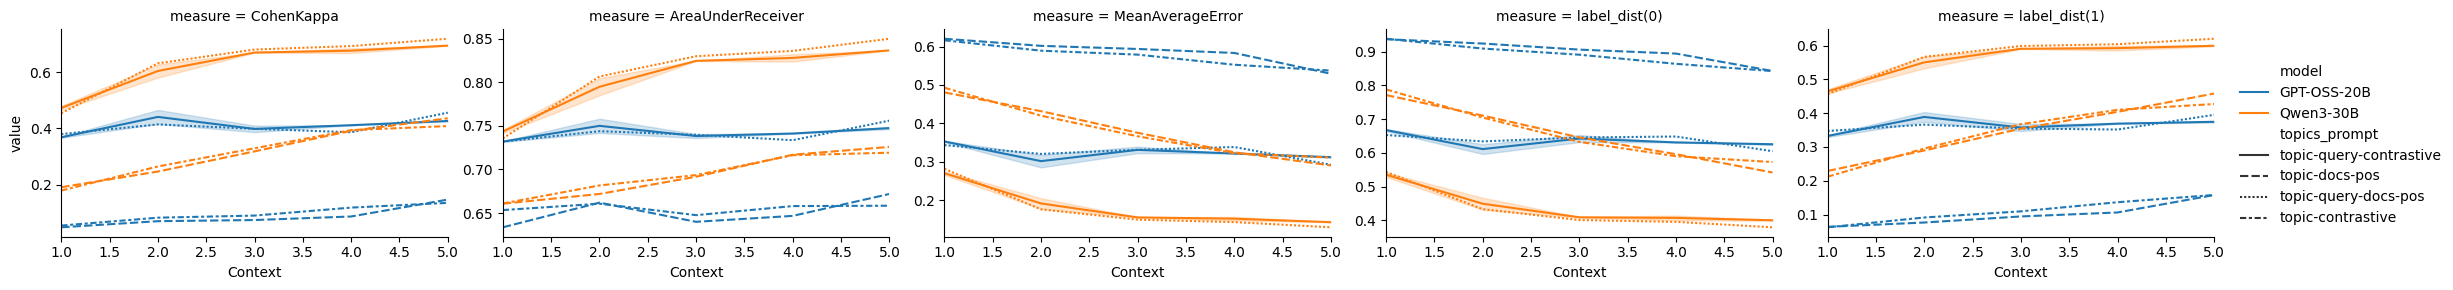

In [ ]:
g = sns.relplot(
    data=df[df["topics_prompt"].isin(['topic-query-docs-pos', 'topic-query-contrastive','topic-contrastive', "topic-docs-pos"])],
    x="topics_ndocspos",
    y="value",
    hue="model",
    style="topics_prompt",
    col="measure",
    kind="line",
    height=3,
    palette=model_colors,
    aspect=1.5,
    facet_kws={"sharey": False},
)

for ax in g.axes.flatten():
    ax.set_xbound(1,5)
    ax.set_xlabel("Context")
#     title = ax.get_title()
#     measure = title.split(" = ")[1].replace(" | field", "")
#     if measure in y_mins:
#         ax.set_ylim(bottom=y_mins[measure])


plt.show()

In [ ]:
def plot(subset_prompt_list, df, x="topics_nqueries"):
    df = df.copy()
    baseline = df[df["topics_prompt"] == "human"]
    df = df[df["topics_prompt"].isin(subset_prompt_list)]
    unique_prompts = df["topics_prompt"].unique()
    palette = sns.color_palette("tab10", len(unique_prompts))
    color_map = dict(zip(unique_prompts, palette))

    for measure_name, g in df.groupby("measure"):
        fig, ax = plt.subplots(figsize=(6, 4))
        g = g.copy()
        # g['ci_lower'] = g['value'] - g['ci']
        # g['ci_upper'] = g['value'] + g['ci']

        sns.lineplot(
            data=g,
            x=x,
            y="value",
            hue="topics_prompt",
            palette=color_map,
            ax=ax,
            errorbar=None
        )
        # for prompt_name, sub_g in g.groupby("topics_prompt"):
        #     sub_g = sub_g.sort_values(x)
        #     color = color_map[prompt_name]

        #     ax.fill_between(
        #         sub_g[x],
        #         sub_g['ci_lower'],
        #         sub_g['ci_upper'],
        #         color=color,
        #         alpha=0.15
        #     )

        ax.axhline(y=float(baseline[baseline["measure"] == measure_name]["value"].iloc[0]), linestyle='--',
                   label=f"Original Topic", color='gray')
        ax.set_title(f"Measure: {measure_name}")

IndexError: single positional indexer is out-of-bounds

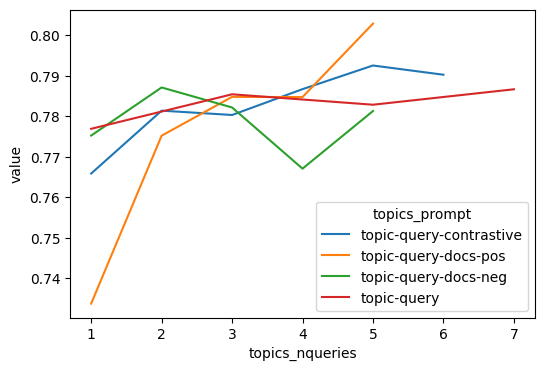

In [ ]:
plot(['topic-query-docs-pos', 'topic-query-docs-neg', 'topic-query', 'topic-query-contrastive'], df)

IndexError: single positional indexer is out-of-bounds

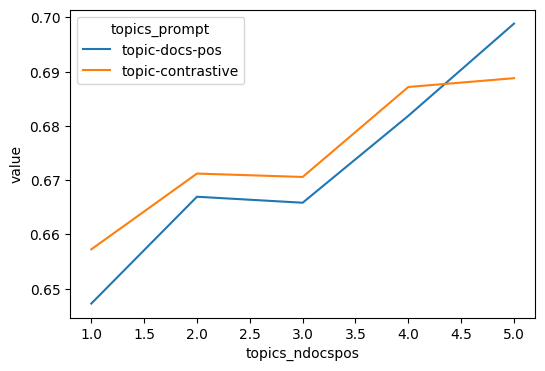

In [ ]:
plot(['topic-docs-pos', 'topic-contrastive'], df, x="topics_ndocspos")

IndexError: single positional indexer is out-of-bounds

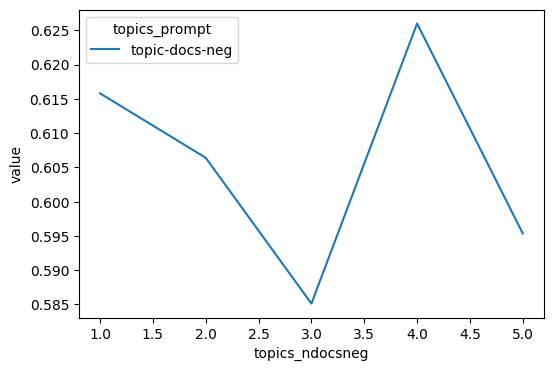

In [ ]:
plot(['topic-docs-neg'], df, x="topics_ndocsneg")